# 07 Your First Deep Learning Project in Python with Keras Step-By-Step

#### Source:

This practical is based on the blog post:

https://machinelearningmastery.com/tutorial-first-neural-network-python-keras/

Here we are going to reproduce parts of that post.
I recommend using Anaconda Python, read the installation guide for it under Unit 7. Use Python 3.x.



### Prerequisites:
Libraries used in this tutorial:
- keras (now built into TensorFlow)
- numpy
- sklearn
- pydot

External libraries (necessary for visualization):
- https://graphviz.gitlab.io/download/

If you set up your machine at home you can remove the cell below

In [1]:
!pip install pydot
!pip install graphviz
!pip install tensorflow

Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable


#### Datasets used
Please download the following datasets and put them into the folder, where this notebook is located (i.e. your working directory):
- https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv
- http://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data
- https://raw.githubusercontent.com/jbrownlee/Datasets/master/housing.data

### Install Tensorflow:

In [2]:
import tensorflow as tf
from tensorflow import keras


In [3]:
from numpy import loadtxt
from keras.models import Sequential
from keras.layers import Dense

# For plotting layers import one of these two:
#from keras.utils.vis_utils import plot_model
from tensorflow.keras.utils import plot_model


import pydot
import matplotlib.pyplot as plt

#### Load the Pima Indian dataset

It is a csv file with ',' as delimiter.

In [4]:
# load the dataset
dataset = loadtxt('pima-indians-diabetes.data.csv', delimiter=',')

The variables can be summarized as follows:

Input Variables (X):

1. Number of times pregnant
2. Plasma glucose concentration a 2 hours in an oral glucose tolerance test
3. Diastolic blood pressure (mm Hg)
4. Triceps skin fold thickness (mm)
5. 2-Hour serum insulin (mu U/ml)
6. Body mass index (weight in kg/(height in m)^2)
7. Diabetes pedigree function
8. Age (years)

Output Variables (Y):

1. Class variable (0 or 1)

# Task 0
What is the size of this dataset? Take a look at a few rows of this dataset to make sure you understand the structure of the data.

In [5]:
# Separate the dataset into input (X) and output (Y) variables
X = dataset[:,0:8]
Y = dataset[:,8]

- The model expects rows of data with 8 variables (the input_dim=8 argument)
- The first hidden layer has 12 nodes and uses the relu activation function.
- The second hidden layer has 8 nodes and uses the relu activation function.
- The output layer has one node and uses the sigmoid activation function.

In [6]:
# define the Keras model
model = Sequential()
model.add(Dense(12, input_dim=8, activation='relu'))
model.add(Dense(8, activation='relu'))
#model.add(Dense(1, activation='sigmoid'))
model.add(Dense(1, activation='sigmoid'))

In [7]:
#Check your model 
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 12)                108       
                                                                 
 dense_1 (Dense)             (None, 8)                 104       
                                                                 
 dense_2 (Dense)             (None, 1)                 9         
                                                                 
Total params: 221 (884.00 Byte)
Trainable params: 221 (884.00 Byte)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


To train a neural network model you will need to specify a loss function, an optimizer, and some metrics for monitoring.

https://www.tensorflow.org/guide/keras/train_and_evaluate/

In [8]:
# compile the Keras model
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

In [9]:
# fit the Keras model on the dataset
history = model.fit(X, Y, epochs=150, batch_size=10)

Epoch 1/150


77/77 [==============================] - 4s 5ms/step - loss: 1.3863 - accuracy: 0.5430
Epoch 2/150
77/77 [==============================] - 0s 5ms/step - loss: 0.9719 - accuracy: 0.6094
Epoch 3/150
77/77 [==============================] - 0s 5ms/step - loss: 0.8694 - accuracy: 0.6003
Epoch 4/150
77/77 [==============================] - 0s 5ms/step - loss: 0.8245 - accuracy: 0.6159
Epoch 5/150
77/77 [==============================] - 0s 5ms/step - loss: 0.8538 - accuracy: 0.6055
Epoch 6/150
77/77 [==============================] - 0s 5ms/step - loss: 0.7424 - accuracy: 0.6536
Epoch 7/150
77/77 [==============================] - 0s 5ms/step - loss: 0.7396 - accuracy: 0.6497
Epoch 8/150
77/77 [==============================] - 0s 5ms/step - loss: 0.7102 - accuracy: 0.6576
Epoch 9/150
77/77 [==============================] - 0s 5ms/step - loss: 0.6957 - accuracy: 0.6615
Epoch 10/150
77/77 [==============================] - 0s 5ms/step - loss: 0.6927 - accuracy: 0.6497
Epoch 1

77/77 [==============================] - 0s 5ms/step - loss: 0.5142 - accuracy: 0.7357
Epoch 79/150
77/77 [==============================] - 0s 4ms/step - loss: 0.5235 - accuracy: 0.7487
Epoch 80/150
77/77 [==============================] - 0s 4ms/step - loss: 0.5024 - accuracy: 0.7500
Epoch 81/150
77/77 [==============================] - 0s 5ms/step - loss: 0.5265 - accuracy: 0.7435
Epoch 82/150
77/77 [==============================] - 0s 5ms/step - loss: 0.5225 - accuracy: 0.7396
Epoch 83/150
77/77 [==============================] - 0s 5ms/step - loss: 0.5117 - accuracy: 0.7526
Epoch 84/150
77/77 [==============================] - 0s 5ms/step - loss: 0.5116 - accuracy: 0.7487
Epoch 85/150
77/77 [==============================] - 0s 5ms/step - loss: 0.4993 - accuracy: 0.7526
Epoch 86/150
77/77 [==============================] - 0s 4ms/step - loss: 0.5152 - accuracy: 0.7552
Epoch 87/150
77/77 [==============================] - 0s 5ms/step - loss: 0.5174 - accuracy: 0.7552
Epoch 88/150


In [10]:
# evaluate the keras model
_, accuracy = model.evaluate(X, Y)
print('Accuracy: %.2f' % (accuracy*100))

24/24 [==============================] - 1s 5ms/step - loss: 0.4651 - accuracy: 0.7812
Accuracy: 78.12


In [11]:
# Plot model
plot_model(model, show_shapes=True, show_layer_names=True)

You must install pydot (`pip install pydot`) and install graphviz (see instructions at https://graphviz.gitlab.io/download/) for plot_model to work.


Text(0, 0.5, 'Cross entropy loss')

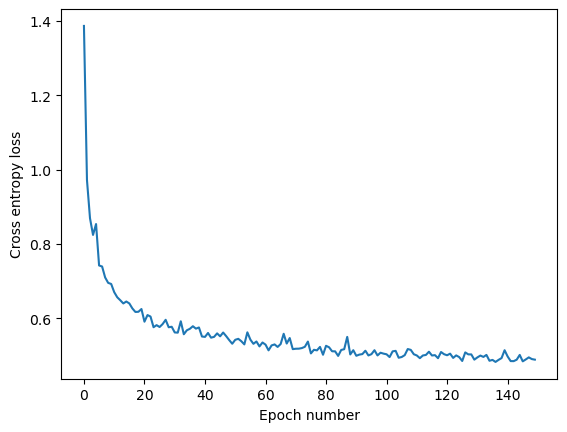

In [12]:
#Plot history
plt.plot(history.history['loss'], label='binary cross entropy loss')
plt.xlabel('Epoch number')
plt.ylabel('Cross entropy loss')

## Predictions

In [13]:
# make probability predictions with the model
predictions = model.predict(X)
# round predictions 
rounded = [round(x[0]) for x in predictions]

24/24 [==============================] - 0s 4ms/step


# Task 1
Create another model (give it a different name) with a slightly different architecture, e.g. with a different number of neurons in the two hidden layers. Specify how many neurons in each layer. Add an extra hidden layer.

In [14]:
# New Keras model 
model2 = Sequential()

# Adding the first hidden layer 
model2.add(Dense(16, input_dim=8, activation='relu'))

# Adding an extra hidden layer 
model2.add(Dense(12, activation='relu'))

# Adding the second hidden layer 
model2.add(Dense(8, activation='relu'))

# Adding the output layer 
model2.add(Dense(1, activation='sigmoid'))

# Task 2

Split the data into a training set (80%) and a validation set (20%), by setting the *validation_split* parameter appropriately in the Keras model. 


In [ ]:
#Importing the train_test_split
from sklearn.model_selection import train_test_split
#dividing the traing and validating set
X_train, X_val, Y_train, Y_val = train_test_split(X, Y, test_size=0.2, random_state=42)
# Compile the model
model2.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
#Using the validation_split parameter
history1 = model2.fit(X_train, Y_train, epochs=150, batch_size=10, validation_split=0.2)

Epoch 1/150
50/50 [==============================] - 3s 16ms/step - loss: 0.4837 - accuracy: 0.7576 - val_loss: 0.5503 - val_accuracy: 0.7073
Epoch 2/150
50/50 [==============================] - 0s 8ms/step - loss: 0.4790 - accuracy: 0.7780 - val_loss: 0.5563 - val_accuracy: 0.7480
Epoch 3/150
50/50 [==============================] - 0s 8ms/step - loss: 0.4860 - accuracy: 0.7556 - val_loss: 0.5644 - val_accuracy: 0.7561
Epoch 4/150
50/50 [==============================] - 0s 7ms/step - loss: 0.4779 - accuracy: 0.7699 - val_loss: 0.5436 - val_accuracy: 0.7398
Epoch 5/150
50/50 [==============================] - 0s 7ms/step - loss: 0.4717 - accuracy: 0.7597 - val_loss: 0.5575 - val_accuracy: 0.7398
Epoch 6/150
50/50 [==============================] - 0s 7ms/step - loss: 0.4780 - accuracy: 0.7515 - val_loss: 0.5465 - val_accuracy: 0.6911
Epoch 7/150
50/50 [==============================] - 0s 7ms/step - loss: 0.4776 - accuracy: 0.7576 - val_loss: 0.5380 - val_accuracy: 0.7398
Epoch 8/150


Epoch 59/150
50/50 [==============================] - 0s 7ms/step - loss: 0.4489 - accuracy: 0.7923 - val_loss: 0.5674 - val_accuracy: 0.7236
Epoch 60/150
50/50 [==============================] - 0s 7ms/step - loss: 0.4493 - accuracy: 0.7780 - val_loss: 0.5997 - val_accuracy: 0.7154
Epoch 61/150
50/50 [==============================] - 0s 7ms/step - loss: 0.4432 - accuracy: 0.7678 - val_loss: 0.5704 - val_accuracy: 0.7398
Epoch 62/150
50/50 [==============================] - 0s 7ms/step - loss: 0.4354 - accuracy: 0.7882 - val_loss: 0.5854 - val_accuracy: 0.7154
Epoch 63/150
50/50 [==============================] - 0s 7ms/step - loss: 0.4379 - accuracy: 0.7800 - val_loss: 0.5770 - val_accuracy: 0.7236
Epoch 64/150
50/50 [==============================] - 0s 7ms/step - loss: 0.4446 - accuracy: 0.7984 - val_loss: 0.5679 - val_accuracy: 0.7073
Epoch 65/150
50/50 [==============================] - 0s 7ms/step - loss: 0.4365 - accuracy: 0.8126 - val_loss: 0.5892 - val_accuracy: 0.7236
Epoch 

# Task 3 

Visualize the performance of your model during training by using the history dictionary object (part of model.fit()). Plot training loss and validation loss against Epoch.

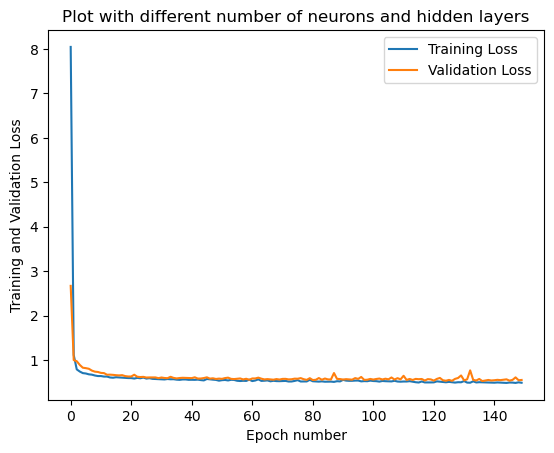

In [16]:
#Plot history for training loss set
plt.plot(history1.history['loss'], label='Training Loss')
plt.plot(history1.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch number')
plt.ylabel('Training and Validation Loss')
plt.title('Plot with different number of neurons and hidden layers')
plt.legend()

# Task 4

Using your model from *Task 1* change the activation functions and see how this affects training.

In [17]:
#Please post your solution here.
#Feel free to add markdown and code cells as you need
model2_changed = Sequential()

# Change activation functions in the hidden layers
model2_changed.add(Dense(16, input_dim=8, activation='tanh'))  # Changed to tanh
model2_changed.add(Dense(12, activation='sigmoid'))  # Changed to sigmoid
model2_changed.add(Dense(8, activation='relu'))  # Kept relu in the third hidden layer

# Add the output layer (binary classification)
model2_changed.add(Dense(1, activation='sigmoid'))

# Compile the model
model2_changed.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
history2 = model2_changed.fit(X_train, Y_train, epochs=150, batch_size=10, validation_split=0.2)



Epoch 1/150
50/50 [==============================] - 4s 18ms/step - loss: 0.7637 - accuracy: 0.3360 - val_loss: 0.7007 - val_accuracy: 0.4146
Epoch 2/150
50/50 [==============================] - 0s 8ms/step - loss: 0.6780 - accuracy: 0.6029 - val_loss: 0.6704 - val_accuracy: 0.6098
Epoch 3/150
50/50 [==============================] - 0s 8ms/step - loss: 0.6450 - accuracy: 0.6640 - val_loss: 0.6671 - val_accuracy: 0.6098
Epoch 4/150
50/50 [==============================] - 0s 7ms/step - loss: 0.6382 - accuracy: 0.6640 - val_loss: 0.6681 - val_accuracy: 0.6098
Epoch 5/150
50/50 [==============================] - 0s 8ms/step - loss: 0.6361 - accuracy: 0.6640 - val_loss: 0.6679 - val_accuracy: 0.6098
Epoch 6/150
50/50 [==============================] - 0s 7ms/step - loss: 0.6360 - accuracy: 0.6640 - val_loss: 0.6675 - val_accuracy: 0.6098
Epoch 7/150
50/50 [==============================] - 0s 8ms/step - loss: 0.6332 - accuracy: 0.6640 - val_loss: 0.6693 - val_accuracy: 0.6098
Epoch 8/150


Epoch 59/150
50/50 [==============================] - 0s 8ms/step - loss: 0.5701 - accuracy: 0.6864 - val_loss: 0.6041 - val_accuracy: 0.6748
Epoch 60/150
50/50 [==============================] - 0s 8ms/step - loss: 0.5754 - accuracy: 0.6762 - val_loss: 0.5930 - val_accuracy: 0.6829
Epoch 61/150
50/50 [==============================] - 0s 7ms/step - loss: 0.5720 - accuracy: 0.6864 - val_loss: 0.5896 - val_accuracy: 0.6829
Epoch 62/150
50/50 [==============================] - 0s 7ms/step - loss: 0.5760 - accuracy: 0.6884 - val_loss: 0.5859 - val_accuracy: 0.6992
Epoch 63/150
50/50 [==============================] - 0s 7ms/step - loss: 0.5729 - accuracy: 0.6721 - val_loss: 0.5999 - val_accuracy: 0.6748
Epoch 64/150
50/50 [==============================] - 0s 7ms/step - loss: 0.5716 - accuracy: 0.6864 - val_loss: 0.5989 - val_accuracy: 0.6829
Epoch 65/150
50/50 [==============================] - 0s 7ms/step - loss: 0.5723 - accuracy: 0.6884 - val_loss: 0.6002 - val_accuracy: 0.6911
Epoch 

50/50 [==============================] - 0s 7ms/step - loss: 0.5616 - accuracy: 0.6721 - val_loss: 0.6178 - val_accuracy: 0.6504
Epoch 117/150
50/50 [==============================] - 0s 8ms/step - loss: 0.5624 - accuracy: 0.6619 - val_loss: 0.6178 - val_accuracy: 0.6504
Epoch 118/150
50/50 [==============================] - 0s 8ms/step - loss: 0.5602 - accuracy: 0.6823 - val_loss: 0.6231 - val_accuracy: 0.6423
Epoch 119/150
50/50 [==============================] - 0s 7ms/step - loss: 0.5584 - accuracy: 0.6823 - val_loss: 0.6145 - val_accuracy: 0.6667
Epoch 120/150
50/50 [==============================] - 0s 7ms/step - loss: 0.5576 - accuracy: 0.6864 - val_loss: 0.6274 - val_accuracy: 0.6504
Epoch 121/150
50/50 [==============================] - 0s 7ms/step - loss: 0.5589 - accuracy: 0.6721 - val_loss: 0.6160 - val_accuracy: 0.6504
Epoch 122/150
50/50 [==============================] - 0s 8ms/step - loss: 0.5693 - accuracy: 0.6802 - val_loss: 0.6221 - val_accuracy: 0.6504
Epoch 123/150

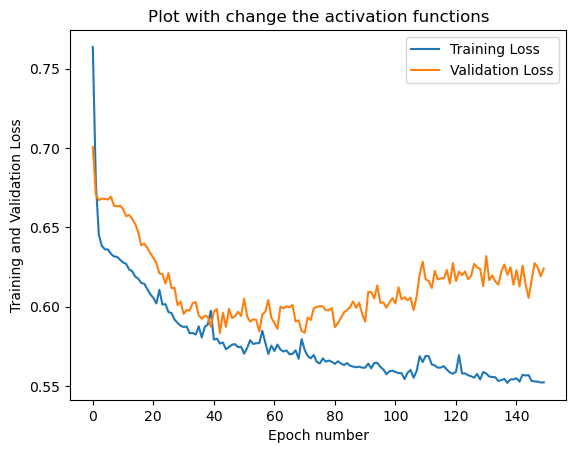

In [18]:
#Plot history
plt.plot(history2.history['loss'], label='Training Loss')
plt.plot(history2.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch number')
plt.ylabel('Training and Validation Loss')
plt.title('Plot with change the activation functions')
plt.legend()

# Task 5

Increase the number of epochs. See what happens.

In [19]:
#Please post your solution here.
#Feel free to add markdown and code cells as you need

# Instantiate the model (Task 1 model)
model2_echo_changed = Sequential()
model2_echo_changed.add(Dense(16, input_dim=8, activation='relu'))
model2_echo_changed.add(Dense(12, activation='relu'))
model2_echo_changed.add(Dense(8, activation='relu'))
model2_echo_changed.add(Dense(1, activation='sigmoid'))

# Compile the model
model2_echo_changed.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

history3 = model2_echo_changed.fit(X_train, Y_train, epochs=200, batch_size=10, validation_split=0.2)

Epoch 1/200
50/50 [==============================] - 4s 17ms/step - loss: 1.9862 - accuracy: 0.4705 - val_loss: 1.7955 - val_accuracy: 0.5041
Epoch 2/200
50/50 [==============================] - 0s 8ms/step - loss: 1.1010 - accuracy: 0.5458 - val_loss: 1.2672 - val_accuracy: 0.5854
Epoch 3/200
50/50 [==============================] - 0s 7ms/step - loss: 0.8890 - accuracy: 0.6334 - val_loss: 0.9420 - val_accuracy: 0.5772
Epoch 4/200
50/50 [==============================] - 0s 7ms/step - loss: 0.8685 - accuracy: 0.6090 - val_loss: 0.8924 - val_accuracy: 0.6341
Epoch 5/200
50/50 [==============================] - 0s 8ms/step - loss: 0.7185 - accuracy: 0.6456 - val_loss: 0.7958 - val_accuracy: 0.6423
Epoch 6/200
50/50 [==============================] - 0s 8ms/step - loss: 0.7100 - accuracy: 0.6619 - val_loss: 0.7916 - val_accuracy: 0.6423
Epoch 7/200
50/50 [==============================] - 0s 7ms/step - loss: 0.6926 - accuracy: 0.6497 - val_loss: 0.6877 - val_accuracy: 0.6341
Epoch 8/200


Epoch 59/200
50/50 [==============================] - 0s 7ms/step - loss: 0.5348 - accuracy: 0.7495 - val_loss: 0.5099 - val_accuracy: 0.7317
Epoch 60/200
50/50 [==============================] - 0s 7ms/step - loss: 0.5289 - accuracy: 0.7699 - val_loss: 0.5378 - val_accuracy: 0.7154
Epoch 61/200
50/50 [==============================] - 0s 7ms/step - loss: 0.5270 - accuracy: 0.7454 - val_loss: 0.5153 - val_accuracy: 0.7154
Epoch 62/200
50/50 [==============================] - 0s 7ms/step - loss: 0.5250 - accuracy: 0.7637 - val_loss: 0.5421 - val_accuracy: 0.7154
Epoch 63/200
50/50 [==============================] - 0s 7ms/step - loss: 0.5804 - accuracy: 0.7251 - val_loss: 0.4823 - val_accuracy: 0.7642
Epoch 64/200
50/50 [==============================] - 0s 7ms/step - loss: 0.5628 - accuracy: 0.7413 - val_loss: 0.4873 - val_accuracy: 0.7480
Epoch 65/200
50/50 [==============================] - 0s 7ms/step - loss: 0.5139 - accuracy: 0.7719 - val_loss: 0.4843 - val_accuracy: 0.7724
Epoch 

50/50 [==============================] - 0s 7ms/step - loss: 0.4711 - accuracy: 0.7902 - val_loss: 0.4657 - val_accuracy: 0.8049
Epoch 117/200
50/50 [==============================] - 0s 7ms/step - loss: 0.4849 - accuracy: 0.7739 - val_loss: 0.4737 - val_accuracy: 0.7805
Epoch 118/200
50/50 [==============================] - 0s 9ms/step - loss: 0.4880 - accuracy: 0.7637 - val_loss: 0.4980 - val_accuracy: 0.7154
Epoch 119/200
50/50 [==============================] - 0s 8ms/step - loss: 0.4875 - accuracy: 0.7536 - val_loss: 0.4634 - val_accuracy: 0.7561
Epoch 120/200
50/50 [==============================] - 0s 9ms/step - loss: 0.4792 - accuracy: 0.7719 - val_loss: 0.4837 - val_accuracy: 0.8049
Epoch 121/200
50/50 [==============================] - 0s 7ms/step - loss: 0.4813 - accuracy: 0.7841 - val_loss: 0.4862 - val_accuracy: 0.7561
Epoch 122/200
50/50 [==============================] - 0s 7ms/step - loss: 0.4883 - accuracy: 0.7739 - val_loss: 0.4774 - val_accuracy: 0.7724
Epoch 123/200

50/50 [==============================] - 0s 7ms/step - loss: 0.4955 - accuracy: 0.7678 - val_loss: 0.4538 - val_accuracy: 0.7967
Epoch 174/200
50/50 [==============================] - 0s 7ms/step - loss: 0.4576 - accuracy: 0.7780 - val_loss: 0.4774 - val_accuracy: 0.8049
Epoch 175/200
50/50 [==============================] - 0s 7ms/step - loss: 0.4442 - accuracy: 0.7923 - val_loss: 0.5181 - val_accuracy: 0.7642
Epoch 176/200
50/50 [==============================] - 0s 7ms/step - loss: 0.4483 - accuracy: 0.7902 - val_loss: 0.4712 - val_accuracy: 0.8049
Epoch 177/200
50/50 [==============================] - 0s 7ms/step - loss: 0.4674 - accuracy: 0.7678 - val_loss: 0.4653 - val_accuracy: 0.8049
Epoch 178/200
50/50 [==============================] - 0s 8ms/step - loss: 0.4545 - accuracy: 0.7800 - val_loss: 0.4608 - val_accuracy: 0.7561
Epoch 179/200
50/50 [==============================] - 0s 7ms/step - loss: 0.4356 - accuracy: 0.7862 - val_loss: 0.5491 - val_accuracy: 0.7642
Epoch 180/200

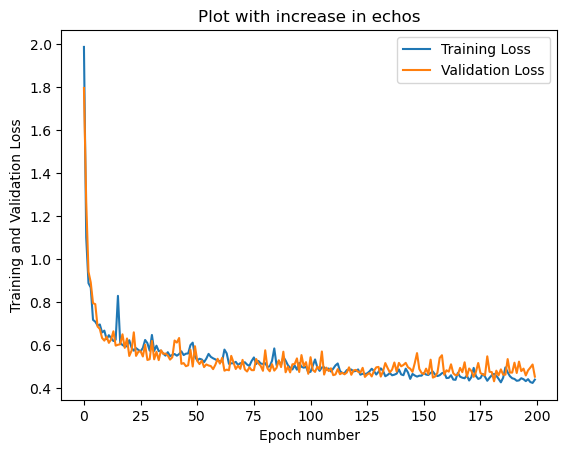

In [20]:
#plot history
plt.plot(history3.history['loss'], label='Training Loss')
plt.plot(history3.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch number')
plt.ylabel('Training and Validation Loss')
plt.title('Plot with increase in echos')
plt.legend()

# Task 6 (optional)

Try similar steps for the multiclass tutorial:

https://machinelearningmastery.com/multi-class-classification-tutorial-keras-deep-learning-library/